In [2]:
import numpy as np
from itertools import product


grid = np.array([
    [1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1],
    [0, 0, 1, 1, 0],
    [1, 0, 0, 1, 1],
])

print(grid)

[[1 0 1 1 0]
 [0 1 1 0 1]
 [1 1 0 0 1]
 [0 0 1 1 0]
 [1 0 0 1 1]]


In [ ]:

def build_table(grid):
    # counts[(L, R)] = [n0, n1]  -> how often centre was 0 / 1 for that pattern
    counts = {pattern: [0, 0] for pattern in product([0, 1], repeat=2)}
    rows, cols = grid.shape

    # horizontal triples: L C R = grid[r, c-1], grid[r, c], grid[r, c+1]
    for r in range(rows):
        for c in range(1, cols - 1):
            L, C, R = grid[r, c-1], grid[r, c], grid[r, c+1]
            counts[(L, R)][C] += 1

    # vertical triples: L C R = grid[r-1, c], grid[r, c], grid[r+1, c]
    for c in range(cols):
        for r in range(1, rows - 1):
            L, C, R = grid[r-1, c], grid[r, c], grid[r+1, c]
            counts[(L, R)][C] += 1

    return counts

def print_table(counts):
    print(" L  R | count(C=0) | count(C=1) | P(C=1)")
    print("------+------------+------------+-------")
    for (L, R), (n0, n1) in counts.items():
        total = n0 + n1
        p = n1 / total if total > 0 else float("nan")
        print(f" {L}  {R} | {n0:^10} | {n1:^10} | {p:.3f}")

counts = build_table(grid)
print_table(counts)

In [ ]:
import numpy as np

rng = np.random.default_rng(0)          # seed -> same set every run
grids = rng.integers(0, 2, size=(100000, 3, 3))   

print(grids.shape)      

print(grids[0])         


## make prob table with distinct patterns 

In [ ]:
from collections import defaultdict

def neighbours_and_centre(g):
    flat = g.flatten()               # index 4 is the middle
    centre = int(flat[4])
    neigh = tuple(int(x) for i, x in enumerate(flat) if i != 4)  # 8 outer cells
    return neigh, centre

def build_table(grids):
    counts = defaultdict(lambda: [0, 0])   # neighbours -> [n0, n1]
    for g in grids:
        neigh, centre = neighbours_and_centre(g)
        counts[neigh][centre] += 1
    return counts

table = build_table(grids)
print(f"{len(table)} distinct patterns seen, out of {2**8} possible")

In [ ]:
import numpy as np

def predict_centre(neigh, table):
    n0, n1 = table.get(neigh, [0, 0])
    total = n0 + n1
    if total == 0:
        return None, float("nan")
    p1 = n1 / total
    return (1 if p1 >= 0.5 else 0), p1

def show_hidden(g):
    for r in range(3):
        print(" ".join("?" if (r, c) == (1, 1) else str(int(g[r, c])) for c in range(3)))

i = np.random.default_rng().integers(0, len(grids))   # pick one of our grids
test = grids[i]
neigh, true_centre = neighbours_and_centre(test)
guess, p1 = predict_centre(neigh, table)

print(f"Chosen grid index: {i}")
print("Grid (middle hidden):")
show_hidden(test)
print(f"\nP(centre=1) = {p1:.3f}")
print(f"Prediction: {guess}")

In [ ]:
print("Grid (revealed):")
for r in range(3):
    print(" ".join(str(int(test[r, c])) for c in range(3)))
print(f"\nActual centre: {true_centre}")
print("Correct!" if guess == true_centre else "Wrong.")

## reflection and rotation pooling

In [ ]:


def neigh_tuple(g):
    flat = g.flatten()
    return tuple(int(x) for i, x in enumerate(flat) if i != 4)   # 8 outer cells

def key_symmetry(g):
    """Canonical 8-neighbour key over 4 rotations + 4 reflections (D4)."""
    variants = []
    m = g
    for _ in range(4):
        variants.append(neigh_tuple(m))
        variants.append(neigh_tuple(np.fliplr(m)))
        m = np.rot90(m)
    return min(variants)

def centre_of(g):
    return int(g.flatten()[4])

def build_table(grids, key_fn):
    counts = defaultdict(lambda: [0, 0])
    for g in grids:
        counts[key_fn(g)][centre_of(g)] += 1
    return counts

table_sym = build_table(grids, key_symmetry)
print(f"{len(table_sym)} distinct classes, out of {2**8} raw patterns , Burnside's lemma")

In [ ]:
def predict_centre(g, table, key_fn):
    n0, n1 = table.get(key_fn(g), [0, 0])
    total = n0 + n1
    if total == 0:
        return None, float("nan")
    p1 = n1 / total
    return (1 if p1 >= 0.5 else 0), p1

def show_hidden(g):
    for r in range(3):
        print(" ".join("?" if (r, c) == (1, 1) else str(int(g[r, c])) for c in range(3)))

i = np.random.default_rng().integers(0, len(grids))
test = grids[i]
guess, p1 = predict_centre(test, table_sym, key_symmetry)
true_centre = centre_of(test)

print(f"Chosen grid index: {i}")
print("Grid (middle hidden):")
show_hidden(test)
print(f"\nP(centre=1) = {p1:.3f}")
print(f"Prediction: {guess}")

In [ ]:
print("Grid (revealed):")
for r in range(3):
    print(" ".join(str(int(test[r, c])) for c in range(3)))
print(f"\nActual centre: {true_centre}")
print("Correct!" if guess == true_centre else "Wrong.")

## whihc method is closests to 50/50

In [ ]:
def average_prob(table):
    probs = [n1 / (n0 + n1) for n0, n1 in table.values() if (n0 + n1) > 0]
    return sum(probs) / len(probs)

print("rigid   :", average_prob(table))
print("symmetry:", average_prob(table_sym))

# try with making our own gauss fields and then making prob table 

In [45]:
import numpy as np
from scipy.ndimage import gaussian_filter
from collections import defaultdict
import matplotlib.pyplot as plt

def make_field(size=64, scale=1.0, seed=0):
    rng = np.random.default_rng(seed)
    noise  = rng.standard_normal((size, size))
    smooth = gaussian_filter(noise, sigma=scale)
    return (smooth > np.median(smooth)).astype(int)

X = 100
fields = [make_field(seed=s) for s in range(X)]   # different seed -> different field
print(len(fields), "fields of shape", fields[0].shape)

100 fields of shape (64, 64)


In [46]:
def neigh_tuple(g):
    flat = g.flatten()
    return tuple(int(x) for i, x in enumerate(flat) if i != 4)

def key_rigid(g):  return neigh_tuple(g)

def key_symmetry(g):
    variants, m = [], g
    for _ in range(4):
        variants.append(neigh_tuple(m))
        variants.append(neigh_tuple(np.fliplr(m)))
        m = np.rot90(m)
    return min(variants)

def centre_of(g):  return int(g.flatten()[4])

def build_table(fields, key_fn):
    counts = defaultdict(lambda: [0, 0])
    for f in fields:
        size = f.shape[0]
        for r in range(1, size - 1):
            for c in range(1, size - 1):
                g = f[r-1:r+2, c-1:c+2]
                counts[key_fn(g)][centre_of(g)] += 1
    return counts

In [47]:
table = build_table(fields, key_rigid)
print("rigid classes:", len(table))

rigid classes: 256


In [48]:
table_sym = build_table(fields, key_symmetry)
print("symmetry classes:", len(table_sym))

symmetry classes: 51


In [50]:

field = make_field(seed=np.random.randint(1000,10000) ,scale=1.0)

# pick a random 3x3 window
rng = np.random.default_rng()
r = rng.integers(1, field.shape[0] - 1)
c = rng.integers(1, field.shape[1] - 1)
g = field[r-1:r+2, c-1:c+2]

def prob(g, tbl, key_fn):
    n0, n1 = tbl.get(key_fn(g), [0, 0])
    t = n0 + n1
    return n1 / t if t else float("nan")

print("Neighbourhood (centre hidden):")
for i in range(3):
    print(" ".join("?" if (i, j) == (1, 1) else str(g[i, j]) for j in range(3)))

p_rigid = prob(g, table,     key_rigid)
p_sym   = prob(g, table_sym, key_symmetry)
print(f"\nrigid   : P(centre=1) = {p_rigid:.3f}  -> guess {int(p_rigid >= 0.5)}")
print(f"symmetry: P(centre=1) = {p_sym:.3f}  -> guess {int(p_sym >= 0.5)}")
print(f"\nReal centre: {centre_of(g)}")

Neighbourhood (centre hidden):
1 1 1
0 ? 1
0 0 0

rigid   : P(centre=1) = 0.494  -> guess 0
symmetry: P(centre=1) = 0.496  -> guess 0

Real centre: 0


# starting with gauss

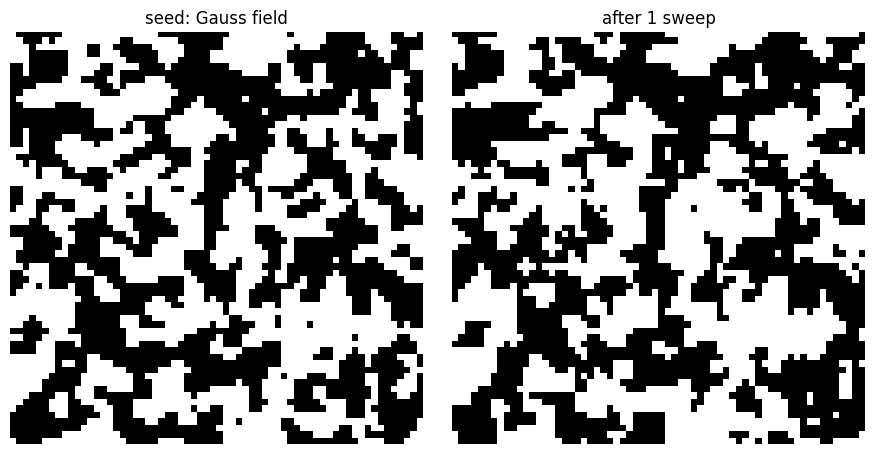

In [75]:
def grow_from(start, sweeps=1, seed=0):
    rng = np.random.default_rng(seed)
    f = start.copy()
    size = f.shape[0]
    for _ in range(sweeps):
        for r in range(size):
            for c in range(size):
                g = f[np.ix_([(r-1)%size, r, (r+1)%size],
                             [(c-1)%size, c, (c+1)%size])]
                f[r, c] = 1 if rng.random() < p1_lookup(g) else 0
    return f

# seed = a fresh Gauss field with the SAME parameters as training
seed_field = make_field(seed=999, scale=1.0)
grown = grow_from(seed_field, sweeps=1)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(seed_field, cmap="gray"); ax[0].set_title("seed: Gauss field")
ax[1].imshow(grown, cmap="gray");      ax[1].set_title("after 1 sweep")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## random nosie

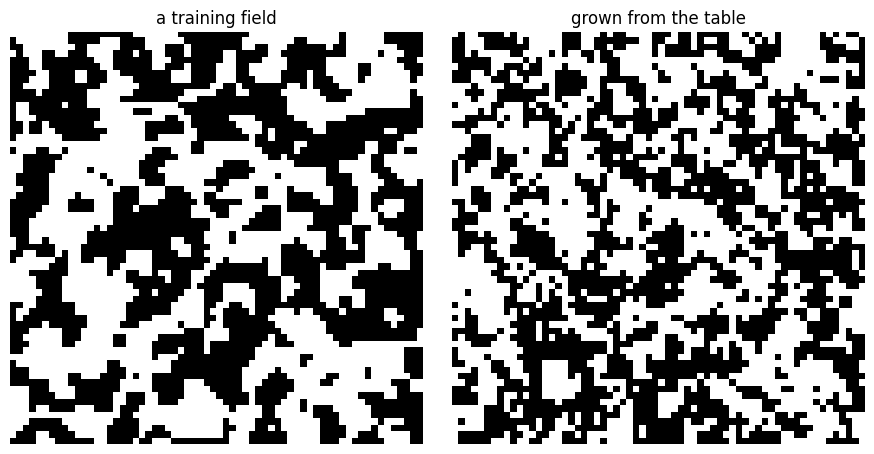

In [77]:


#grow a NEW field from the table by Gibbs sampling
def p1_lookup(g):
    n0, n1 = table.get(key_rigid(g), [0, 0])
    t = n0 + n1
    return n1 / t if t else 0.5          # unseen pattern -> coin flip

def grow_field(size=64, sweeps=1, seed=0):
    rng = np.random.default_rng(seed)
    f = rng.integers(0, 2, size=(size, size))     # start from noise
    for _ in range(sweeps):
        for r in range(size):
            for c in range(size):
                g = f[np.ix_([(r-1)%size, r, (r+1)%size],   # 3x3, wraps at edges
                             [(c-1)%size, c, (c+1)%size])]
                f[r, c] = 1 if rng.random() < p1_lookup(g) else 0   # SAMPLE
    return f

new = grow_field()

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(train[0], cmap="gray"); ax[0].set_title("a training field")
ax[1].imshow(new, cmap="gray");      ax[1].set_title("grown from the table")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()